In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntProgress, Label
from IPython.display import display

## Network initialization

Where we start is very important. This is the part where I figured out things hard way. We need asymmetry in the weights, otherwise the multiple neurons are adjusted to very similar hyperplanes, which is not very useful. So,
* Uniform often wins empirically
* Normal has better theoretical properties

More importantly,
* Proper variance scaling
* Assymmetry
* Weights should neither be too small/too large, to prevent gradient explosion or vanishing.

https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf

In [2]:
def xavier_uniform(output_size, input_size):
    limit = np.sqrt(6.0 / (input_size + output_size))
    return np.random.uniform(-limit, limit, (output_size, input_size))

In [3]:
class Layer:
    def __init__(self, insize, neurons, f, df):
        self.insize = insize
        self.neurons = neurons
        self.f = f
        self.df = df

        self.w = xavier_uniform(neurons, insize)
        self.b = np.random.uniform(-1, 1, neurons) # biases

## Einstein summation notation

Writing a stochastic gradient descent, taking one point at a time is fairly straightforward. But doing that in mini-batch needs special numpy function `einsum`. It lets us express, succintly what we are trying to achieve. 

https://numpy.org/doc/2.2/reference/generated/numpy.einsum.html

TLDR:
Explicit form is very powerful and more intuitive to understand than the implicit form. 
Express the indexes to the dimension of each argument to the left side of `->` 
* if there are common index usages on arguments they are multiplied 
* if an index doesn't appear on the rightside they are added

Eg: 'ij,jk -> ik' does regular matrix multiplication.

In [4]:
def backpropagate(layers, xs, ys, loss, dloss, learning_rate=0.01):
    dl_dw = [np.zeros_like(layer.w) for layer in layers]  # gradients for each layer
    dl_db = [np.zeros_like(layer.b) for layer in layers]  # gradients for biases

    # Forward pass
    forward = [xs]
    a = []  # weighted sums
    for layer in layers:
        sum = np.einsum('ij,kj -> ki', layer.w, forward[-1]) + layer.b.reshape(1, -1)
        a.append(sum)
        forward.append(layer.f(sum))  # apply activation function

    py = forward[-1]  # output of the last layer
    dl_dx = dloss(ys.reshape(-1, 1), py)
 

    # Backward pass
    for i in reversed(range(len(layers))):
        layer = layers[i]
        
        # Zoom in on the current layer
        xi = forward[i]
        ai = a[i]
        yi = forward[i + 1]

        # next layer's input is current layer's output, so chain rule is intuitive
        dl_dy = dl_dx
        dl_da = dl_dy * layer.df(ai, yi)
        dl_dw[i] = np.einsum('ki, kj -> ij', dl_da, xi)  # outer product for gradients
        dl_db[i] = dl_da.sum(axis=0)  # biases are summed, so no outer product needed

        # Housekeeping for previous layer.
        dl_dx = np.einsum('ij, ki -> kj', layer.w, dl_da)

    # Update weights and biases
    for i, layer in enumerate(layers):
        layer.w -= learning_rate * dl_dw[i]
        layer.b -= learning_rate * dl_db[i]



In [5]:
batch_size = 128
def gradient_descent(layers, x, y, loss, dloss, epochs=1000, learning_rate=0.01):
    progress = IntProgress(min=0, max=epochs, description='')
    label = Label('Starting Gradient Descent...')
    display(progress, label)
    for epoch in range(epochs):
        for i in range(0, len(x), batch_size):
            batch_x = x[i:i+batch_size]
            batch_y = y[i:i+batch_size]
            backpropagate(layers, batch_x, batch_y, loss, dloss, learning_rate)
        progress.value = epoch + 1
        label.value = f'Epoch {epoch + 1}/{epochs} completed'
    label.value = 'Training Completed'

        
        
def predict(layers, x):
    result = x
    for layer in layers:
        result = layer.f(layer.w @ result + layer.b)
    return result

## Activation / Loss Functions and their derivatives.

We start with only `sigmoid` activation. Note: `np.clip` clips the range of the values to the out of the range to the edge of the range.
In case of loss functions, we could use binary cross entropy, incase of binary classification problem or sum squared error in case of regression (we might need a different activation at the output at the very least in case of regression). We clip the probabilities so we dont get divide by 0 issues.

In [6]:
def sigmoid(x):
    # Simple but effective approach
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def dsigmoid(x, y):
    return y * (1 - y)

In [7]:
def cross_entropy(y, py):
    eps = 1e-15
    py = np.clip(py, eps, 1 - eps)
    return -y * np.log(py) - (1 - y) * np.log(1 - py)

def dcross_entropy(y, py):
    eps = 1e-15
    py = np.clip(py, eps, 1 - eps)
    return (py - y) / (py * (1 - py))

def se(y, py):
    return 0.5 * np.sum((y - py) ** 2)

def dse(y, py):
    return py - y  # derivative of squared error is simply the difference

# Prepare the data

We will train a neural network to identify points within a circle. This would be an experiment to understand the expressive capability of the deep neural networks. So we won't do training/test split and measure errors and so on, we are just going to visually confirm if it the final model looks like a circle or not.

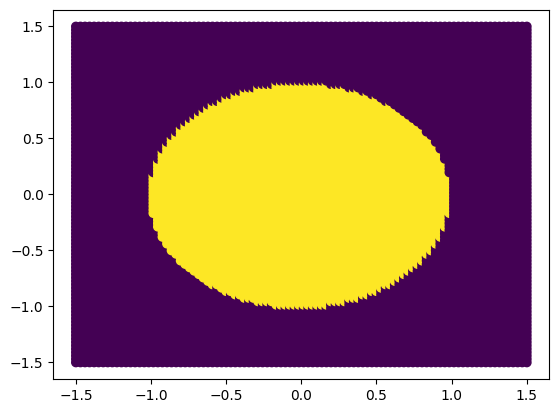

In [8]:
r = np.linspace(-1.5, 1.5, 100)

x = []
y = []

for i in r:
    for j in r:
        x.append([i, j])
        y.append(1.0 if i**2 + j**2 < 1 else 0.0)
        
x = np.array(x)
y = np.array(y)


plt.scatter(x[:, 0], x[:, 1], c=y)

# Network definition

We will build a network with takes x-y co-ordinates and classify whether its in a circle or not. We will use a network with 2 hidden layers of 4 neurons each and output layer. All the activation function being sigmoid. 

Note: We calculate out mean prediction to with the randomly initialized network to see if our initial prediction is close to 0.5.

In [9]:
layers = [
    Layer(2, 4, sigmoid, dsigmoid),  # Hidden layer with 2 inputs, 4 neurons
    Layer(4, 4, sigmoid, dsigmoid),  # Hidden layer with 4 inputs, 4 neurons
    Layer(4, 1, sigmoid, dsigmoid),  # Output layer with 4 inputs, 1 neurons
]


np.array([predict(layers, x[i]) for i in range(len(x))]).mean()

np.float64(0.4088143529198572)

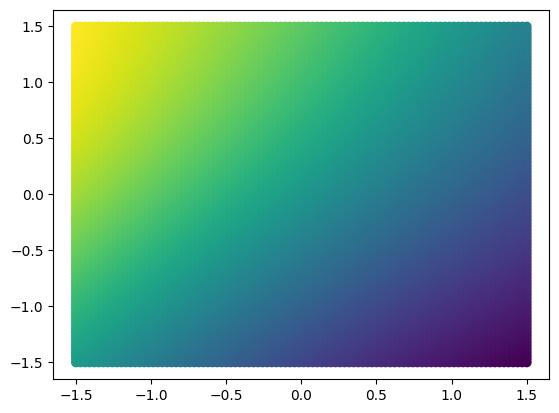

In [10]:
def draw_current_map():
    predictions = np.array([predict(layers, x[i]) for i in range(len(x))])
    xT = x.T
    plt.scatter(xT[0], xT[1], c=predictions)

draw_current_map()

In [11]:
gradient_descent(layers,
                x,
                y,
                cross_entropy,
                dcross_entropy,
                epochs=5000,
                learning_rate=0.0001)

IntProgress(value=0, max=5000)

Label(value='Starting Gradient Descent...')

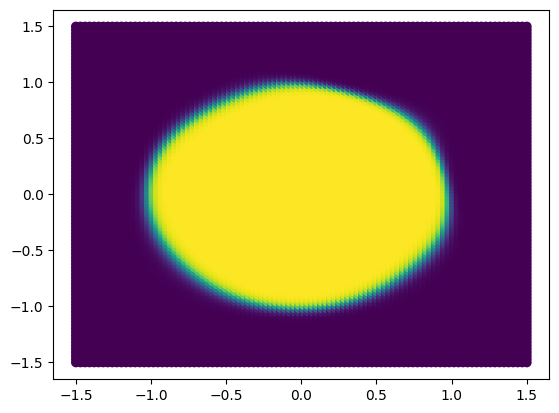

In [12]:
draw_current_map()